# DBSCAN Clustering Notebook

#### Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

#### Reading the dataset

In [2]:
sys.path.append('..')
from src.data import load_data
df = load_data('../data/cleaned_log_data.csv')
df.head()

,Unnamed: 0,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0,2,3,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,1,2,3,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,2,2,3,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,3,1,3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,4,2,3,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


In [3]:
df.shape

(395, 9)

In [4]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']

X_data = np.asanyarray(df[features])
X_data

array([[ 9.44699227,  9.17543832,  8.93089098,  5.37063803,  7.89170466,
         7.19967835],
       [ 8.861917  ,  9.19125948,  9.16628399,  7.47477218,  8.09985791,
         7.48268183],
       [ 8.75683981,  9.08352921,  8.94702566,  7.7857209 ,  8.16536363,
         8.96763167],
       ...,
       [10.57717155,  7.26682735,  6.63987583,  8.41427414,  4.54329478,
         7.7608932 ],
       [ 9.58410839,  9.64788537, 10.3170531 ,  6.08221891,  9.60521628,
         7.53262362],
       [ 9.23902501,  7.59186171,  7.71110125,  6.94601399,  5.12989871,
         7.66199756]], shape=(395, 6))

#### Visualizing the scaled data distribution

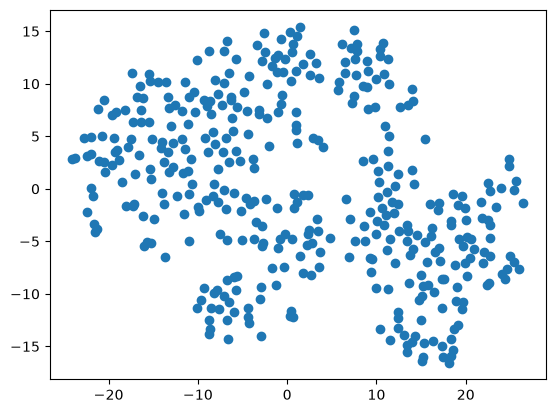

In [5]:
from src.clustering import tsne_model
from sklearn.preprocessing import StandardScaler

X_s = StandardScaler().fit_transform(X_data)
model = tsne_model(X_s)

plt.scatter(model[:,0], model[:,1])

#### Model Training

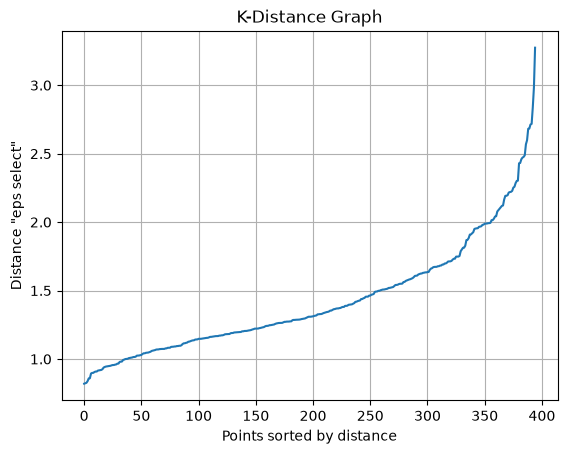

In [6]:
# drow K-Distance Graph to find Elbow and select eps
from src.clustering import k_distance_graph
k_distance_graph(X_data)

#### According to K-Distance Graph, I choosed (1.8, 2.0) for eps

In [7]:
from src.clustering import dbscan_grid
labels = dbscan_grid(X_data, np.arange(1.8, 2.1, 0.1))

eps=1.80  k=1  noise=3.5%  (Just One Cluster)
eps=1.90  k=1  noise=2.5%  (Just One Cluster)
eps=2.00  k=1  noise=1.0%  (Just One Cluster)
eps=2.10  k=1  noise=1.0%  (Just One Cluster)
------------------------------------------------------------------------
eps is None. One cluster


Text(0.5, 1.0, 'Hierarchical Clustering')

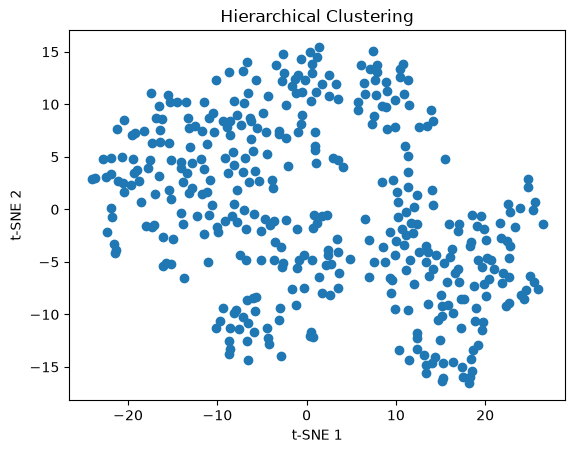

In [8]:
X_scaled = StandardScaler().fit_transform(X_data)

tsne_vis = tsne_model(X_scaled)

plt.scatter(tsne_vis[: , 0], tsne_vis[: , 1] , c = labels)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Hierarchical Clustering')

#### The algorithm's performance with the previous `eps` parameter was very poor; it identified the entire dataset as a single cluster. for the next step, I will reduce the `eps` value.

In [9]:
labels_2 = dbscan_grid(X_data, np.arange(1.0, 1.8, 0.1))

eps=1.00  k=2  noise=69.6%  sil=0.482
eps=1.10  k=1  noise=45.8%  (Just One Cluster)
eps=1.20  k=1  noise=30.9%  (Just One Cluster)
eps=1.30  k=1  noise=22.8%  (Just One Cluster)
eps=1.40  k=1  noise=18.0%  (Just One Cluster)
eps=1.50  k=1  noise=12.9%  (Just One Cluster)
eps=1.60  k=1  noise=8.1%  (Just One Cluster)
eps=1.70  k=1  noise=5.3%  (Just One Cluster)
------------------------------------------------------------------------

Best: eps=1.00, k=2, noise=69.6%, sil=0.482


Text(0.5, 1.0, 'Hierarchical Clustering')

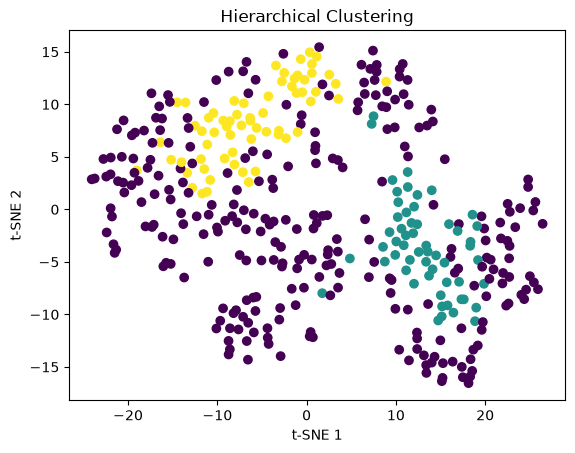

In [10]:
tsne_vis = tsne_model(X_scaled)

plt.scatter(tsne_vis[: , 0], tsne_vis[: , 1] , c = labels_2)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Hierarchical Clustering')

#### At this stage, the algorithm yielded two clusters—along with a very `high noise` level of `69.6%—indicating` the absence of a suitable intermediate state.
#### Next, we turn to the **HDBSCAN** algorithm, as it does not require a fixed `eps` value and handles varying cluster densities more effectively.

In [11]:
from src.clustering import hdbscan_grid
cluster_size = [8, 12, 15, 20]
min_samples = [None, 5, 10]
labels_hdb = hdbscan_grid(X_data, cluster_size, min_samples)

mcs=8 ms=None k=2 noise=78.0% sil=0.542
mcs=8 ms=5 k=2 noise=82.3% sil=0.535
mcs=8 ms=10 k=2 noise=79.5% sil=0.543
mcs=12 ms=None k=2 noise=81.8% sil=0.553
mcs=12 ms=5 k=2 noise=82.3% sil=0.535
mcs=12 ms=10 k=2 noise=79.5% sil=0.543
mcs=15 ms=None k=2 noise=81.8% sil=0.555
mcs=15 ms=5 k=2 noise=82.3% sil=0.535
mcs=15 ms=10 k=2 noise=79.5% sil=0.543
mcs=20 ms=None k=2 noise=81.0% sil=0.543
mcs=20 ms=5 k=2 noise=82.3% sil=0.535
mcs=20 ms=10 k=2 noise=79.5% sil=0.543

Best: mcs=15, ms=None, sil=0.555


Text(0.5, 1.0, 'Hierarchical Clustering')

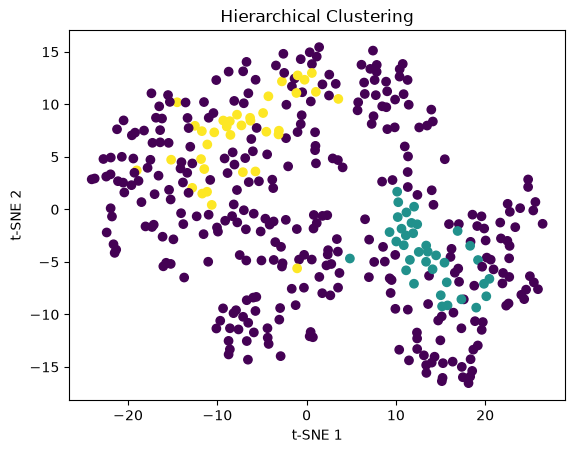

In [12]:
tsne_vis = tsne_model(X_scaled)

plt.scatter(tsne_vis[: , 0], tsne_vis[: , 1] , c = labels_hdb)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Hierarchical Clustering')

## Conclusion
The `HDBSCAN` algorithm performed slightly better than `DBSCAN`, as it managed to split the data into `two` clusters; however, a major issue—despite the consistency of the results—is that nearly all outcomes identified between `78%` and `82.3%` of the data as noise. This indicates that **density-based algorithms like DBSCAN and HDBSCAN are unsuitable for this dataset, at least without dimensionality reduction.**